# Step-34.3: Regime-Specific Persistence Execution Engine

## Financial Market Trend Forecasting Using Ensemble Learning and Deep Sequence Models

This notebook redesigns the **execution layer only** for the fixed Step-28 cross-sectional alpha signal.  
It implements **regime-specific persistence logic** to reduce churn, improve cost-adjusted deployability, and preserve alpha after realistic execution frictions.

## Strict Chronology and Anti-Leakage Contract

The notebook enforces institutional anti-leakage mechanics:

1. Signals and target weights are formed on date **t**.
2. Realized PnL on date **t** uses **weights from t-1** only.
3. No same-row signal/return contamination is allowed.
4. Volatility estimates for sizing use shifted history only.
5. Assertions and diagnostics explicitly validate chronology.

Formally: **weights[t-1] -> returns[t]**.

## Regime-Specific Persistence Economics

- **HIGH regime**: faster alpha decay, shorter persistence, tighter exits.
- **MEDIUM regime**: moderate persistence with selective entries.
- **LOW regime**: strongest persistence, widest deadbands, longest holding.

Execution is persistence-first: retain unless deterioration is material and replacement superiority exceeds explicit thresholds after cost-aware suppression.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 400)
pd.set_option("display.width", 260)

CFG = {
    "start_date": "2023-01-01",
    "end_date": "2026-01-01",
    "annualization_days": 252,
    "vol_lookback": 40,
    "vol_floor": 1e-4,
    "target_gross": 1.0,
    "max_single_weight": 0.08,
    "max_net_exposure": 0.12,
    "tx_cost_bps": 20.0,
    "slippage_bps": 5.0,
    "stress_bps": [10, 20, 30, 50, 75, 100],
    "regimes": ["HIGH", "MEDIUM", "LOW"],
    "min_universe": 20,
}

REGIME_CFG = {
    "HIGH": {
        "long_entry": 0.87,
        "short_entry": 0.13,
        "long_exit": 0.44,
        "short_exit": 0.56,
        "long_retain": 0.58,
        "short_retain": 0.42,
        "rank_deterioration": 0.10,
        "no_trade_deadband": 0.006,
        "resize_deadband": 0.010,
        "min_hold": 2,
        "max_hold": 10,
        "replacement_superiority": 0.08,
        "turnover_tolerance": 0.33,
        "max_resize_step": 0.030,
        "max_longs": 5,
        "max_shorts": 5,
    },
    "MEDIUM": {
        "long_entry": 0.90,
        "short_entry": 0.10,
        "long_exit": 0.42,
        "short_exit": 0.58,
        "long_retain": 0.63,
        "short_retain": 0.37,
        "rank_deterioration": 0.09,
        "no_trade_deadband": 0.008,
        "resize_deadband": 0.013,
        "min_hold": 3,
        "max_hold": 14,
        "replacement_superiority": 0.10,
        "turnover_tolerance": 0.26,
        "max_resize_step": 0.022,
        "max_longs": 4,
        "max_shorts": 4,
    },
    "LOW": {
        "long_entry": 0.92,
        "short_entry": 0.08,
        "long_exit": 0.38,
        "short_exit": 0.62,
        "long_retain": 0.70,
        "short_retain": 0.30,
        "rank_deterioration": 0.07,
        "no_trade_deadband": 0.012,
        "resize_deadband": 0.018,
        "min_hold": 4,
        "max_hold": 20,
        "replacement_superiority": 0.14,
        "turnover_tolerance": 0.20,
        "max_resize_step": 0.015,
        "max_longs": 4,
        "max_shorts": 3,
    },
}

UNIFORM_CFG = {
    r: {
        "long_entry": 0.89,
        "short_entry": 0.11,
        "long_exit": 0.42,
        "short_exit": 0.58,
        "long_retain": 0.62,
        "short_retain": 0.38,
        "rank_deterioration": 0.09,
        "no_trade_deadband": 0.009,
        "resize_deadband": 0.014,
        "min_hold": 3,
        "max_hold": 14,
        "replacement_superiority": 0.10,
        "turnover_tolerance": 0.27,
        "max_resize_step": 0.020,
        "max_longs": 4,
        "max_shorts": 4,
    }
    for r in CFG["regimes"]
}


def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for p in [cwd, cwd.parent, cwd.parent.parent]:
        if (p / "ml_pipeline").exists():
            return p
    raise FileNotFoundError("Could not resolve project root containing ml_pipeline")


ROOT = resolve_project_root()
BASE = ROOT / "ml_pipeline"
FINAL_DIR = BASE / "Market_Data" / "final"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

ALPHA_PATH = FINAL_DIR / "cross_sectional_alpha_results.parquet"
STEP33_PATH = FINAL_DIR / "step33_cost_aware_portfolio.parquet"
STEP34_PATH = FINAL_DIR / "step34_low_turnover_portfolio.parquet"
STEP341_PATH = FINAL_DIR / "step34_1_threshold_rebalance_portfolio.parquet"
STEP342_PATH = FINAL_DIR / "step34_2_persistence_engine.parquet"
FINAL_MODEL_PATH = BASE / "Market_Data" / "processed" / "final_model_dataset.parquet"

OUT_PORT = FINAL_DIR / "step34_3_regime_persistence.parquet"
OUT_REG = FINAL_DIR / "step34_3_regime_analysis.csv"
OUT_TURN = FINAL_DIR / "step34_3_turnover_analysis.csv"
OUT_LS = FINAL_DIR / "step34_3_long_short_analysis.csv"
OUT_SUM = FINAL_DIR / "step34_3_persistence_summary.csv"

assert ALPHA_PATH.exists(), f"Missing required input: {ALPHA_PATH}"


In [2]:
def prepare_alpha_frame(alpha_path: Path, cfg: dict, final_model_path: Optional[Path] = None) -> pd.DataFrame:
    raw = pd.read_parquet(alpha_path).copy()
    raw_cols = {c.lower(): c for c in raw.columns}

    # Normalize key fields from either expected schema or project schema.
    ticker_col = raw_cols.get("ticker")
    date_col = raw_cols.get("date")
    pred_col = raw_cols.get("pred_score")
    if pred_col is None:
        pred_candidates = [c for c in raw.columns if c.lower().startswith("pred_")]
        if "pred_LightGBMRegressor" in raw.columns:
            pred_col = "pred_LightGBMRegressor"
        elif pred_candidates:
            pred_col = pred_candidates[0]
    ret_col = raw_cols.get("actual_return")
    regime_col = raw_cols.get("regime")

    if ticker_col is None or date_col is None or pred_col is None:
        raise ValueError("Input must include ticker/date/prediction fields")

    x = raw.rename(columns={ticker_col: "ticker", date_col: "date", pred_col: "pred_score"})
    x["date"] = pd.to_datetime(x["date"])
    x = x[(x["date"] >= pd.Timestamp(cfg["start_date"])) & (x["date"] <= pd.Timestamp(cfg["end_date"]))].copy()

    # If actual_return/regime missing, enrich from project processed dataset and construct regime from shifted volatility tertiles.
    if (ret_col is None or regime_col is None) and final_model_path is not None and final_model_path.exists():
        fm = pd.read_parquet(final_model_path, columns=["Ticker", "Date", "Close"])
        fm = fm.rename(columns={"Ticker": "ticker", "Date": "date"}).copy()
        fm["date"] = pd.to_datetime(fm["date"])
        fm = fm.sort_values(["ticker", "date"])
        fm["actual_return"] = fm.groupby("ticker")["Close"].pct_change()
        fm["ret_shift_1"] = fm.groupby("ticker")["actual_return"].shift(1)
        fm["vol_rank_source"] = (
            fm.groupby("ticker")["ret_shift_1"]
            .rolling(cfg["vol_lookback"], min_periods=10)
            .std()
            .reset_index(level=0, drop=True)
        )
        fm["vol_rank_source"] = fm["vol_rank_source"].fillna(fm.groupby("date")["vol_rank_source"].transform("median"))
        fm["vol_rank_source"] = fm["vol_rank_source"].fillna(fm["vol_rank_source"].median())
        fm["vol_rank_pct"] = fm.groupby("date")["vol_rank_source"].rank(pct=True, method="average")
        fm["regime"] = np.select(
            [fm["vol_rank_pct"] >= (2.0 / 3.0), fm["vol_rank_pct"] >= (1.0 / 3.0)],
            ["HIGH", "MEDIUM"],
            default="LOW",
        )
        enrich = fm[["ticker", "date", "actual_return", "regime"]]
        x = x.merge(enrich, on=["ticker", "date"], how="left")
    else:
        x = x.rename(columns={ret_col: "actual_return", regime_col: "regime"})

    x["regime"] = x["regime"].astype(str).str.upper()
    x = x[x["regime"].isin(cfg["regimes"])].copy()
    x = x.sort_values(["date", "ticker"]).reset_index(drop=True)

    # If returns still missing, compute directly from alpha source (if close exists).
    if x["actual_return"].isna().all() and "Close" in x.columns:
        x["actual_return"] = x.groupby("ticker")["Close"].pct_change()

    x = x.dropna(subset=["actual_return", "pred_score"]).copy()

    # Cross-sectional rank for signal thresholds.
    x["rank_pct"] = x.groupby("date")["pred_score"].rank(pct=True, method="average")

    # Shifted (t-1) volatility estimate by ticker; never same-row.
    x["ret_shift_1"] = x.groupby("ticker")["actual_return"].shift(1)
    x["vol_est"] = (
        x.groupby("ticker")["ret_shift_1"]
        .rolling(cfg["vol_lookback"], min_periods=10)
        .std()
        .reset_index(level=0, drop=True)
    )
    x["vol_est"] = x["vol_est"].fillna(x.groupby("date")["vol_est"].transform("median"))
    x["vol_est"] = x["vol_est"].fillna(x["vol_est"].median())
    x["vol_est"] = x["vol_est"].clip(lower=cfg["vol_floor"])
    x["inv_vol"] = 1.0 / x["vol_est"]

    # Standardized score used in superiority checks.
    x["score_z"] = x.groupby("date")["pred_score"].transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-12))

    # Diagnostics for integrity.
    assert x["date"].is_monotonic_increasing, "Data must be sorted by date"
    assert x[["pred_score", "actual_return", "rank_pct", "inv_vol"]].isna().sum().sum() == 0, "Unexpected NaNs"

    # Chronology check: first row per ticker cannot have shifted return.
    first_idx = x.groupby("ticker", as_index=False)["date"].idxmin()["date"].values
    assert x.loc[first_idx, "ret_shift_1"].isna().all(), "Shift violation in volatility construction"

    # Explicit leakage check: same-day return must not be exactly the shifted return where available.
    valid = x["ret_shift_1"].notna()
    same_rate = (np.isclose(x.loc[valid, "actual_return"], x.loc[valid, "ret_shift_1"], atol=1e-14)).mean()
    assert same_rate < 0.02, "Suspicious same-row contamination in returns"

    daily_n = x.groupby("date")["ticker"].nunique()
    x = x[x["date"].isin(daily_n[daily_n >= CFG["min_universe"]].index)].copy()
    return x


df = prepare_alpha_frame(ALPHA_PATH, CFG, FINAL_MODEL_PATH)
print(f"Prepared panel: {df.shape}, dates={df['date'].nunique()}, tickers={df['ticker'].nunique()}")
display(df.head(3))


Prepared panel: (4900, 22), dates=245, tickers=96


,ticker,date,target_future_return_t3,target_rank_cs,target_zscore_cs,pred_XGBoostRegressor,pred_score,side,weight,portfolio_return_component,daily_portfolio_return,model_selected,ic_mean_selected,ic_std_selected,sharpe_selected,actual_return,regime,rank_pct,ret_shift_1,vol_est,inv_vol,score_z
0,ADANIENT,2025-01-01,-0.031470,0.250000,-0.679717,0.025071,0.023142,1,0.1,-0.003147,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,0.010361,HIGH,0.95,NaN,0.023142,43.212343,1.656570
1,ADANIPORTS,2025-01-01,-0.045663,0.104167,-1.090849,0.023497,0.009093,1,0.1,-0.004566,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,-0.010072,HIGH,0.60,NaN,0.023142,43.212343,0.469329
2,ADANIPOWER,2025-01-01,-0.053831,0.062500,-1.327426,0.023923,0.009626,1,0.1,-0.005383,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,-0.005288,HIGH,0.80,NaN,0.023142,43.212343,0.514341


In [3]:
@dataclass
class PositionState:
    entry_date: pd.Timestamp
    side: int
    regime: str
    age: int
    gross_pnl: float = 0.0
    net_pnl: float = 0.0
    turnover_paid: float = 0.0


class RegimeSpecificPersistenceEngine:
    def __init__(self, base_cfg: dict, regime_cfg: Dict[str, dict], name: str):
        self.base_cfg = base_cfg
        self.regime_cfg = regime_cfg
        self.name = name

        self.cur_w: Dict[str, float] = {}
        self.cur_rank: Dict[str, float] = {}
        self.pos_state: Dict[str, PositionState] = {}
        self.daily_rows: List[dict] = []
        self.panel_rows: List[dict] = []
        self.turnover_rows: List[dict] = []
        self.closed_positions: List[dict] = []

    def _regime_cfg(self, regime: str) -> dict:
        return self.regime_cfg.get(regime, self.regime_cfg["MEDIUM"])

    def _normalize_weights(self, target: Dict[str, float], day_map: pd.DataFrame) -> Dict[str, float]:
        if not target:
            return {}
        t = {k: float(v) for k, v in target.items() if np.isfinite(v) and abs(v) > 0}
        if not t:
            return {}

        # Single-name cap.
        cap = self.base_cfg["max_single_weight"]
        t = {k: float(np.clip(v, -cap, cap)) for k, v in t.items()}

        # Gross normalization.
        gross = sum(abs(v) for v in t.values())
        if gross > 0:
            scale = self.base_cfg["target_gross"] / gross
            t = {k: v * scale for k, v in t.items()}

        # Net control (do not claim beta neutrality).
        net = sum(t.values())
        max_net = self.base_cfg["max_net_exposure"]
        if abs(net) > max_net:
            adj = (abs(net) - max_net) * np.sign(net)
            pos = [k for k, v in t.items() if np.sign(v) == np.sign(net)]
            denom = sum(abs(t[k]) for k in pos) + 1e-12
            for k in pos:
                t[k] -= adj * abs(t[k]) / denom

        # Re-normalize gross after net adjustment.
        gross2 = sum(abs(v) for v in t.values())
        if gross2 > 0:
            t = {k: v * (self.base_cfg["target_gross"] / gross2) for k, v in t.items()}
        return t

    def _candidate_targets(self, g: pd.DataFrame) -> Dict[str, float]:
        picks = []
        for regime, gr in g.groupby("regime"):
            rc = self._regime_cfg(regime)
            longs = gr[gr["rank_pct"] >= rc["long_entry"]].nlargest(rc["max_longs"], "rank_pct")
            shorts = gr[gr["rank_pct"] <= rc["short_entry"]].nsmallest(rc["max_shorts"], "rank_pct")
            if len(longs):
                ll = longs[["ticker", "inv_vol"]].copy()
                ll["side"] = 1
                ll["regime"] = regime
                picks.append(ll)
            if len(shorts):
                ss = shorts[["ticker", "inv_vol"]].copy()
                ss["side"] = -1
                ss["regime"] = regime
                picks.append(ss)

        if not picks:
            return {}
        p = pd.concat(picks, ignore_index=True)
        p = p.drop_duplicates(subset=["ticker"], keep="first")

        # Side buckets with inverse-vol sizing.
        out: Dict[str, float] = {}
        for side, gside in p.groupby("side"):
            invv = gside["inv_vol"].clip(lower=1e-12)
            alloc = invv / invv.sum()
            side_gross = 0.5
            for t, a in zip(gside["ticker"], alloc):
                out[t] = float(side * side_gross * a)
        return self._normalize_weights(out, g)

    def _replacement_superiority(self, side: int, regime: str, current_score_z: float, g: pd.DataFrame) -> float:
        rc = self._regime_cfg(regime)
        if side > 0:
            pool = g[g["rank_pct"] >= rc["long_entry"]]
            if len(pool) == 0:
                return 0.0
            best = float(pool["score_z"].max())
            return best - current_score_z
        pool = g[g["rank_pct"] <= rc["short_entry"]]
        if len(pool) == 0:
            return 0.0
        best_short = float(pool["score_z"].min())
        return current_score_z - best_short

    def _should_exit(self, t: str, row: pd.Series, g: pd.DataFrame) -> Tuple[bool, str]:
        w0 = self.cur_w.get(t, 0.0)
        if abs(w0) == 0:
            return False, "not_held"
        side = 1 if w0 > 0 else -1
        regime = str(row["regime"])
        rc = self._regime_cfg(regime)
        rank = float(row["rank_pct"])
        score_z = float(row["score_z"])
        age = self.pos_state[t].age if t in self.pos_state else 0

        prev_rank = self.cur_rank.get(t, rank)
        adverse_deterioration = (prev_rank - rank) if side > 0 else (rank - prev_rank)

        if age < rc["min_hold"]:
            severe = (rank <= rc["long_exit"]) if side > 0 else (rank >= rc["short_exit"])
            return (True, "early_severe_invalidation") if severe else (False, "forced_min_hold")

        if age >= rc["max_hold"]:
            weak = (rank < rc["long_retain"]) if side > 0 else (rank > rc["short_retain"])
            return (True, "max_hold_reached") if weak else (False, "max_hold_but_strong")

        hard_exit = (rank <= rc["long_exit"]) if side > 0 else (rank >= rc["short_exit"])
        if hard_exit:
            return True, "hard_rank_exit"

        if adverse_deterioration >= rc["rank_deterioration"]:
            sup = self._replacement_superiority(side, regime, score_z, g)
            if sup >= rc["replacement_superiority"]:
                return True, "replacement_superiority"

        retain_cut = rc["long_retain"] if side > 0 else rc["short_retain"]
        weak_retention = (rank < retain_cut) if side > 0 else (rank > retain_cut)
        if weak_retention:
            sup = self._replacement_superiority(side, regime, score_z, g)
            if sup >= rc["replacement_superiority"]:
                return True, "retention_failure"

        return False, "retain"

    def _apply_persistence(self, g: pd.DataFrame, target_raw: Dict[str, float]) -> Tuple[Dict[str, float], List[dict]]:
        desired: Dict[str, float] = dict(self.cur_w)
        reasons: List[dict] = []

        ticker_map = g.set_index("ticker")

        # Exit evaluation for held names.
        for t in list(self.cur_w.keys()):
            if t not in ticker_map.index:
                desired[t] = 0.0
                reasons.append({"ticker": t, "reason": "missing_row_exit"})
                continue
            row = ticker_map.loc[t]
            go_exit, reason = self._should_exit(t, row, g)
            if go_exit:
                desired[t] = 0.0
            reasons.append({"ticker": t, "reason": reason})

        # Entry logic for candidates not currently held.
        for t, tw in target_raw.items():
            if abs(self.cur_w.get(t, 0.0)) > 0:
                continue
            row = ticker_map.loc[t]
            rc = self._regime_cfg(str(row["regime"]))
            side = 1 if tw > 0 else -1
            rank = float(row["rank_pct"])
            entry_ok = rank >= rc["long_entry"] if side > 0 else rank <= rc["short_entry"]
            if not entry_ok:
                continue
            # Selective entry superiority (vs side median) to avoid weak churn.
            if side > 0:
                med = float(g[g["rank_pct"] >= 0.5]["score_z"].median()) if (g["rank_pct"] >= 0.5).any() else 0.0
                if float(row["score_z"]) - med < (0.5 * rc["replacement_superiority"]):
                    continue
            else:
                med = float(g[g["rank_pct"] < 0.5]["score_z"].median()) if (g["rank_pct"] < 0.5).any() else 0.0
                if med - float(row["score_z"]) < (0.5 * rc["replacement_superiority"]):
                    continue
            desired[t] = tw

        # Persistence-biased partial resizing.
        out: Dict[str, float] = {}
        for t in sorted(set(desired) | set(target_raw) | set(self.cur_w)):
            w0 = float(self.cur_w.get(t, 0.0))
            wd = float(desired.get(t, 0.0))
            if t not in ticker_map.index:
                continue
            regime = str(ticker_map.loc[t, "regime"])
            rc = self._regime_cfg(regime)
            delta = wd - w0
            if abs(delta) <= rc["no_trade_deadband"]:
                w1 = w0
            elif abs(delta) <= rc["resize_deadband"]:
                w1 = w0
            else:
                step = np.sign(delta) * min(abs(delta), rc["max_resize_step"])
                w1 = w0 + step

            if abs(w1) < 1e-6:
                continue
            out[t] = float(w1)

        # Turnover suppression by weighted tolerance.
        if out or self.cur_w:
            all_t = sorted(set(out) | set(self.cur_w))
            turnover = sum(abs(out.get(t, 0.0) - self.cur_w.get(t, 0.0)) for t in all_t)
            tol_numer = 0.0
            tol_denom = 0.0
            for t in all_t:
                if t not in ticker_map.index:
                    continue
                reg = str(ticker_map.loc[t, "regime"])
                rc = self._regime_cfg(reg)
                w_abs = abs(self.cur_w.get(t, 0.0)) + abs(out.get(t, 0.0))
                tol_numer += w_abs * rc["turnover_tolerance"]
                tol_denom += w_abs
            tol = (tol_numer / tol_denom) if tol_denom > 0 else 0.25
            if turnover > tol and turnover > 1e-12:
                scale = tol / turnover
                shrunk = {}
                for t in all_t:
                    w0 = self.cur_w.get(t, 0.0)
                    w1 = out.get(t, 0.0)
                    nw = w0 + (w1 - w0) * scale
                    if abs(nw) > 1e-6:
                        shrunk[t] = float(nw)
                out = shrunk

        out = self._normalize_weights(out, g)
        return out, reasons

    def _update_positions_after_trade(
        self,
        date: pd.Timestamp,
        g: pd.DataFrame,
        prev_w: Dict[str, float],
        new_w: Dict[str, float],
        delta_map: Dict[str, float],
        gross_comp: Dict[str, float],
        cost_comp: Dict[str, float],
    ) -> None:
        gmap = g.set_index("ticker")

        # PnL accrual to positions from previous holdings (weights[t-1] * returns[t]).
        for t, w in prev_w.items():
            if t in self.pos_state:
                self.pos_state[t].gross_pnl += gross_comp.get(t, 0.0)
                self.pos_state[t].net_pnl += gross_comp.get(t, 0.0) - cost_comp.get(t, 0.0)
                self.pos_state[t].turnover_paid += cost_comp.get(t, 0.0)

        prev_set = {t for t, w in prev_w.items() if abs(w) > 1e-9}
        new_set = {t for t, w in new_w.items() if abs(w) > 1e-9}
        entering = new_set - prev_set
        exiting = prev_set - new_set
        staying = prev_set & new_set

        for t in exiting:
            if t in self.pos_state:
                st = self.pos_state.pop(t)
                self.closed_positions.append(
                    {
                        "ticker": t,
                        "entry_date": st.entry_date,
                        "exit_date": date,
                        "holding_days": st.age,
                        "entry_regime": st.regime,
                        "side": st.side,
                        "gross_pnl": st.gross_pnl,
                        "net_pnl": st.net_pnl,
                        "turnover_paid": st.turnover_paid,
                    }
                )

        for t in staying:
            if t in self.pos_state:
                self.pos_state[t].age += 1

        for t in entering:
            if t not in gmap.index:
                continue
            side = 1 if new_w[t] > 0 else -1
            regime = str(gmap.loc[t, "regime"])
            self.pos_state[t] = PositionState(entry_date=date, side=side, regime=regime, age=1)

    def run_backtest(self, panel: pd.DataFrame, tx_bps: float, slippage_bps: float) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        dates = sorted(panel["date"].unique())
        if len(dates) < 2:
            raise ValueError("Need at least 2 dates for lagged execution")
        cost_rate = (tx_bps + slippage_bps) / 1e4

        self.cur_w = {}
        self.cur_rank = {}
        self.pos_state = {}
        self.daily_rows = []
        self.panel_rows = []
        self.turnover_rows = []
        self.closed_positions = []

        lag_return_check = []

        for i, date in enumerate(dates):
            g = panel[panel["date"] == date].copy().sort_values("ticker")
            target = self._candidate_targets(g)
            new_w, reasons = self._apply_persistence(g, target)

            all_t = sorted(set(new_w) | set(self.cur_w) | set(g["ticker"]))
            delta = {t: float(new_w.get(t, 0.0) - self.cur_w.get(t, 0.0)) for t in all_t}
            turnover = float(sum(abs(v) for v in delta.values()))

            # Realized return at date t uses weights from t-1 only.
            gmap = g.set_index("ticker")
            gross_map = {}
            if i == 0:
                gross_ret = 0.0
            else:
                gross_ret = 0.0
                for t in gmap.index:
                    comp = self.cur_w.get(t, 0.0) * float(gmap.loc[t, "actual_return"])
                    gross_map[t] = float(comp)
                    gross_ret += comp

            tx_cost = turnover * cost_rate
            net_ret = gross_ret - tx_cost

            long_gross = float(sum(v for v in gross_map.values() if v >= 0))
            short_gross = float(sum(v for t, v in gross_map.items() if self.cur_w.get(t, 0.0) < 0))

            gross_abs = sum(abs(d) for d in delta.values()) + 1e-12
            cost_map = {t: tx_cost * abs(delta[t]) / gross_abs for t in delta}

            self._update_positions_after_trade(date, g, dict(self.cur_w), dict(new_w), delta, gross_map, cost_map)

            # Store panel-level rows for detailed diagnostics.
            for t in gmap.index:
                w_prev = float(self.cur_w.get(t, 0.0))
                w_new = float(new_w.get(t, 0.0))
                dlt = w_new - w_prev
                self.panel_rows.append(
                    {
                        "date": date,
                        "ticker": t,
                        "regime": str(gmap.loc[t, "regime"]),
                        "pred_score": float(gmap.loc[t, "pred_score"]),
                        "score_z": float(gmap.loc[t, "score_z"]),
                        "rank_pct": float(gmap.loc[t, "rank_pct"]),
                        "actual_return": float(gmap.loc[t, "actual_return"]),
                        "vol_est": float(gmap.loc[t, "vol_est"]),
                        "inv_vol": float(gmap.loc[t, "inv_vol"]),
                        "weight_prev": w_prev,
                        "weight_new": w_new,
                        "delta_weight": dlt,
                        "gross_component": float(gross_map.get(t, 0.0)),
                        "tx_cost_component": float(cost_map.get(t, 0.0)),
                        "net_component": float(gross_map.get(t, 0.0) - cost_map.get(t, 0.0)),
                        "held_prev": int(abs(w_prev) > 1e-9),
                        "held_new": int(abs(w_new) > 1e-9),
                    }
                )

            # Turnover decomposition.
            entered = sum(1 for t in all_t if abs(self.cur_w.get(t, 0.0)) <= 1e-9 and abs(new_w.get(t, 0.0)) > 1e-9)
            exited = sum(1 for t in all_t if abs(self.cur_w.get(t, 0.0)) > 1e-9 and abs(new_w.get(t, 0.0)) <= 1e-9)
            resized = sum(1 for t in all_t if abs(self.cur_w.get(t, 0.0)) > 1e-9 and abs(new_w.get(t, 0.0)) > 1e-9 and abs(delta[t]) > 1e-9)
            overlap = len({t for t in self.cur_w if abs(self.cur_w[t]) > 1e-9} & {t for t in new_w if abs(new_w[t]) > 1e-9})
            held_count = len({t for t, w in self.cur_w.items() if abs(w) > 1e-9})
            overlap_ratio = float(overlap / max(held_count, 1))

            self.turnover_rows.append(
                {
                    "date": date,
                    "turnover": turnover,
                    "entered_count": entered,
                    "exited_count": exited,
                    "resized_count": resized,
                    "overlap_ratio": overlap_ratio,
                }
            )

            avg_age = float(np.mean([s.age for s in self.pos_state.values()])) if self.pos_state else 0.0
            replacement_rate = (entered + exited) / max(1, held_count)
            self.daily_rows.append(
                {
                    "date": date,
                    "strategy": self.name,
                    "gross_return": float(gross_ret),
                    "net_return": float(net_ret),
                    "tx_cost": float(tx_cost),
                    "turnover": float(turnover),
                    "long_gross_component": float(long_gross),
                    "short_gross_component": float(short_gross),
                    "avg_position_age": avg_age,
                    "replacement_rate": float(replacement_rate),
                }
            )

            # Chronology diagnostic: compare lagged-vs-same-day application.
            same_day = float(sum(new_w.get(t, 0.0) * float(gmap.loc[t, "actual_return"]) for t in gmap.index))
            lag_return_check.append({"date": date, "lagged": gross_ret, "same_day": same_day})

            self.cur_w = new_w
            self.cur_rank = {r["ticker"]: float(r["rank_pct"]) for r in g[["ticker", "rank_pct"]].to_dict("records")}

        dly = pd.DataFrame(self.daily_rows).sort_values("date").reset_index(drop=True)
        pnl = pd.DataFrame(self.panel_rows).sort_values(["date", "ticker"]).reset_index(drop=True)
        tdf = pd.DataFrame(self.turnover_rows).sort_values("date").reset_index(drop=True)
        closed = pd.DataFrame(self.closed_positions)

        # Core leakage assertions.
        chk = pd.DataFrame(lag_return_check)
        if len(chk) >= 2:
            assert np.isclose(chk.loc[0, "lagged"], 0.0), "First day lagged return should be zero"
            drift = (chk["lagged"] - chk["same_day"]).abs().iloc[1:].mean()
            assert drift > 1e-8, "Lagged and same-day returns are too close; chronology likely broken"

        return dly, pnl, tdf, closed


def annualized_metrics(dly: pd.DataFrame, return_col: str, turnover_col: str = "turnover") -> dict:
    r = dly[return_col].fillna(0.0).values
    t = dly[turnover_col].fillna(0.0).values if turnover_col in dly else np.zeros_like(r)
    mu = float(np.mean(r))
    sd = float(np.std(r, ddof=0))
    ann_ret = mu * CFG["annualization_days"]
    ann_vol = sd * np.sqrt(CFG["annualization_days"]) if sd > 0 else np.nan
    sharpe = ann_ret / ann_vol if ann_vol and np.isfinite(ann_vol) and ann_vol > 0 else np.nan
    mdd = float((pd.Series((1 + pd.Series(r)).cumprod()).div((1 + pd.Series(r)).cumprod().cummax()).sub(1)).min()) if len(r) else np.nan
    return {
        "annual_return": ann_ret,
        "annual_vol": ann_vol,
        "sharpe": sharpe,
        "avg_turnover": float(np.mean(t)),
        "max_drawdown": mdd,
        "days": len(r),
    }


def apply_cost_scenarios(dly: pd.DataFrame, gross_col: str, turnover_col: str, stress_bps: List[int]) -> pd.DataFrame:
    out = []
    for b in stress_bps:
        cost_rate = b / 1e4
        net = dly[gross_col] - dly[turnover_col] * cost_rate
        temp = dly.copy()
        temp["net_tmp"] = net
        m = annualized_metrics(temp, "net_tmp", turnover_col)
        m["cost_bps"] = b
        out.append(m)
    return pd.DataFrame(out)


def benchmark_from_existing(path: Path, strategy_name: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=["date", "strategy", "gross_return", "net_return", "turnover"])
    x = pd.read_parquet(path)
    if "date" not in x.columns:
        return pd.DataFrame(columns=["date", "strategy", "gross_return", "net_return", "turnover"])

    x = x.copy()
    x["date"] = pd.to_datetime(x["date"])
    ret_candidates = [
        "net_return", "daily_net_return", "portfolio_net_return", "daily_portfolio_return",
        "daily_return", "portfolio_return", "gross_return"
    ]
    turn_candidates = ["turnover", "daily_turnover", "turnover_total"]
    ret_col = next((c for c in ret_candidates if c in x.columns), None)
    turn_col = next((c for c in turn_candidates if c in x.columns), None)
    if ret_col is None:
        return pd.DataFrame(columns=["date", "strategy", "gross_return", "net_return", "turnover"])

    out = x[["date", ret_col]].copy()
    out["gross_return"] = out[ret_col].astype(float)
    out["net_return"] = out[ret_col].astype(float)
    out["turnover"] = x[turn_col].astype(float).values if turn_col else 0.0
    out["strategy"] = strategy_name
    return out[["date", "strategy", "gross_return", "net_return", "turnover"]].sort_values("date")


def build_equal_weight_benchmarks(panel: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    dates = sorted(panel["date"].unique())
    row_ls = []
    row_lo = []
    prev_w_ls = {}
    prev_w_lo = {}
    for i, d in enumerate(dates):
        g = panel[panel["date"] == d].copy()
        g = g.sort_values("rank_pct")
        n = len(g)
        k = max(1, int(0.1 * n))

        longs = g.nlargest(k, "rank_pct")
        shorts = g.nsmallest(k, "rank_pct")

        w_ls = {}
        if len(longs):
            for t in longs["ticker"]:
                w_ls[t] = w_ls.get(t, 0.0) + 0.5 / len(longs)
        if len(shorts):
            for t in shorts["ticker"]:
                w_ls[t] = w_ls.get(t, 0.0) - 0.5 / len(shorts)

        w_lo = {t: 1.0 / len(longs) for t in longs["ticker"]} if len(longs) else {}

        if i == 0:
            gross_ls = 0.0
            gross_lo = 0.0
        else:
            gmap = g.set_index("ticker")
            gross_ls = float(sum(prev_w_ls.get(t, 0.0) * float(gmap.loc[t, "actual_return"]) for t in gmap.index))
            gross_lo = float(sum(prev_w_lo.get(t, 0.0) * float(gmap.loc[t, "actual_return"]) for t in gmap.index))

        turn_ls = float(sum(abs(w_ls.get(t, 0.0) - prev_w_ls.get(t, 0.0)) for t in set(w_ls) | set(prev_w_ls)))
        turn_lo = float(sum(abs(w_lo.get(t, 0.0) - prev_w_lo.get(t, 0.0)) for t in set(w_lo) | set(prev_w_lo)))

        cost_rate = (CFG["tx_cost_bps"] + CFG["slippage_bps"]) / 1e4
        row_ls.append({"date": d, "strategy": "Equal-weight long-short", "gross_return": gross_ls, "net_return": gross_ls - turn_ls * cost_rate, "turnover": turn_ls})
        row_lo.append({"date": d, "strategy": "Long-only benchmark", "gross_return": gross_lo, "net_return": gross_lo - turn_lo * cost_rate, "turnover": turn_lo})

        prev_w_ls = w_ls
        prev_w_lo = w_lo

    return pd.DataFrame(row_ls), pd.DataFrame(row_lo)


In [4]:
engine_regime = RegimeSpecificPersistenceEngine(CFG, REGIME_CFG, "Step-34.3 regime-specific persistence")
dly_r, pnl_r, tdf_r, closed_r = engine_regime.run_backtest(df, tx_bps=CFG["tx_cost_bps"], slippage_bps=CFG["slippage_bps"])

engine_uniform = RegimeSpecificPersistenceEngine(CFG, UNIFORM_CFG, "Uniform persistence rules")
dly_u, pnl_u, tdf_u, closed_u = engine_uniform.run_backtest(df, tx_bps=CFG["tx_cost_bps"], slippage_bps=CFG["slippage_bps"])

# Regime analysis (persistence/turnover/cost drag/alpha efficiency).
reg_rows = []
for reg, gr in pnl_r.groupby("regime"):
    gross = float(gr["gross_component"].sum())
    net = float(gr["net_component"].sum())
    turn = float(gr["delta_weight"].abs().sum())
    alpha_per_turn = (gross / turn) if turn > 1e-12 else np.nan
    hold_days = float(closed_r.loc[closed_r["entry_regime"] == reg, "holding_days"].mean()) if len(closed_r) else np.nan
    repl = float(tdf_r["entered_count"].sum() + tdf_r["exited_count"].sum()) / max(1, len(tdf_r))
    reg_rows.append(
        {
            "regime": reg,
            "gross_pnl": gross,
            "net_pnl": net,
            "cost_drag": gross - net,
            "turnover": turn,
            "alpha_per_turnover": alpha_per_turn,
            "avg_holding_days": hold_days,
            "replacement_rate": repl,
        }
    )
regime_analysis = pd.DataFrame(reg_rows).sort_values("regime").reset_index(drop=True)

# Long vs short persistence analysis.
ls_rows = []
for side, sname in [(1, "LONG"), (-1, "SHORT")]:
    side_df = pnl_r[(pnl_r["weight_prev"] * side) > 0].copy()
    if len(side_df) == 0:
        continue
    gross = float(side_df["gross_component"].sum())
    net = float(side_df["net_component"].sum())
    turn = float(side_df["delta_weight"].abs().sum())
    holding = float(closed_r.loc[closed_r["side"] == side, "holding_days"].mean()) if len(closed_r) else np.nan
    ls_rows.append(
        {
            "side": sname,
            "gross_pnl": gross,
            "net_pnl": net,
            "turnover": turn,
            "avg_holding_days": holding,
            "alpha_per_turnover": (gross / turn) if turn > 1e-12 else np.nan,
            "cost_drag": gross - net,
        }
    )
long_short_analysis = pd.DataFrame(ls_rows)

# Turnover decomposition and persistence frontier.
turnover_analysis = tdf_r.copy()
turnover_analysis["replacement_frequency"] = (turnover_analysis["entered_count"] + turnover_analysis["exited_count"]).astype(float)
turnover_analysis["resizing_frequency"] = turnover_analysis["resized_count"].astype(float)
turnover_analysis["cost_drag"] = turnover_analysis["turnover"] * (CFG["tx_cost_bps"] + CFG["slippage_bps"]) / 1e4
turnover_analysis["alpha_per_turnover"] = dly_r["gross_return"].values / (turnover_analysis["turnover"].replace(0, np.nan).values)
turnover_analysis["alpha_per_turnover"] = turnover_analysis["alpha_per_turnover"].replace([np.inf, -np.inf], np.nan)

# Stress tests.
stress_df = apply_cost_scenarios(dly_r, gross_col="gross_return", turnover_col="turnover", stress_bps=CFG["stress_bps"])

# Benchmarks.
eq_ls, lo_bm = build_equal_weight_benchmarks(df)
bench_frames = [
    benchmark_from_existing(ALPHA_PATH, "Step-28 baseline"),
    benchmark_from_existing(STEP33_PATH, "Step-33 cost-aware"),
    benchmark_from_existing(STEP34_PATH, "Step-34 periodic"),
    benchmark_from_existing(STEP341_PATH, "Step-34.1 threshold"),
    benchmark_from_existing(STEP342_PATH, "Step-34.2 persistence"),
    eq_ls,
    lo_bm,
    dly_r[["date", "gross_return", "net_return", "turnover"]].assign(strategy="Step-34.3 regime-specific persistence"),
    dly_u[["date", "gross_return", "net_return", "turnover"]].assign(strategy="Uniform persistence rules"),
]
bench_all = pd.concat([b for b in bench_frames if len(b) > 0], ignore_index=True)

bench_summary = []
for s, gs in bench_all.groupby("strategy"):
    m_g = annualized_metrics(gs, "gross_return", "turnover")
    m_n = annualized_metrics(gs, "net_return", "turnover")
    bench_summary.append(
        {
            "strategy": s,
            "gross_sharpe": m_g["sharpe"],
            "net_sharpe": m_n["sharpe"],
            "avg_turnover": m_n["avg_turnover"],
            "annual_net_return": m_n["annual_return"],
            "annual_net_vol": m_n["annual_vol"],
            "max_drawdown": m_n["max_drawdown"],
        }
    )
bench_summary = pd.DataFrame(bench_summary).sort_values("net_sharpe", ascending=False).reset_index(drop=True)

# Persistence summary + final verdict logic.
step342_turn = float(bench_summary.loc[bench_summary["strategy"] == "Step-34.2 persistence", "avg_turnover"].iloc[0]) if (bench_summary["strategy"] == "Step-34.2 persistence").any() else 0.89
step343_row = bench_summary[bench_summary["strategy"] == "Step-34.3 regime-specific persistence"]
step343_turn = float(step343_row["avg_turnover"].iloc[0]) if len(step343_row) else np.nan
step343_net_sh = float(step343_row["net_sharpe"].iloc[0]) if len(step343_row) else np.nan
uniform_row = bench_summary[bench_summary["strategy"] == "Uniform persistence rules"]
uniform_net_sh = float(uniform_row["net_sharpe"].iloc[0]) if len(uniform_row) else np.nan

turnover_reduction = (step342_turn - step343_turn) if np.isfinite(step343_turn) else np.nan
deployable = bool(np.isfinite(step343_turn) and np.isfinite(step343_net_sh) and (step343_turn < 0.25) and (step343_net_sh > 0))

if deployable:
    verdict = "PASS"
elif np.isfinite(step343_turn) and np.isfinite(step343_net_sh) and (turnover_reduction > 0) and (step343_net_sh > -0.25):
    verdict = "PARTIAL"
else:
    verdict = "FAIL"

best_reg = regime_analysis.sort_values("alpha_per_turnover", ascending=False).iloc[0]["regime"] if len(regime_analysis) else np.nan
worst_reg = regime_analysis.sort_values("cost_drag", ascending=False).iloc[0]["regime"] if len(regime_analysis) else np.nan
short_weaker = bool(
    len(long_short_analysis) >= 2
    and float(long_short_analysis.loc[long_short_analysis["side"] == "SHORT", "alpha_per_turnover"].iloc[0])
    < float(long_short_analysis.loc[long_short_analysis["side"] == "LONG", "alpha_per_turnover"].iloc[0])
)

final_qa = [
    ("1. Which regime benefits most from persistence?", f"{best_reg} regime (highest alpha-per-turnover)."),
    ("2. Which regime causes most turnover destruction?", f"{worst_reg} regime (largest cost drag)."),
    ("3. Did regime-adaptive execution improve deployability?", "YES" if (np.isfinite(step343_net_sh) and np.isfinite(uniform_net_sh) and step343_net_sh > uniform_net_sh) else "NO"),
    ("4. Did turnover materially decline?", f"YES (Δturnover={turnover_reduction:.4f})" if np.isfinite(turnover_reduction) and turnover_reduction > 0 else "NO"),
    ("5. Is long-short deployment still justified?", "Conditional: longs strong, shorts require tighter filtering." if short_weaker else "Yes, balanced enough."),
    ("6. Should LOW regime be retained?", "YES" if best_reg == "LOW" else "Retain selectively."),
    ("7. Which execution profile was most stable?", "Regime-specific persistence" if (np.isfinite(step343_turn) and step343_turn <= float(uniform_row['avg_turnover'].iloc[0]) if len(uniform_row) else True) else "Uniform profile"),
    ("8. Is the strategy economically deployable now?", "YES" if verdict == "PASS" else ("FRAGILE" if verdict == "PARTIAL" else "NO")),
]
summary_df = pd.DataFrame(final_qa, columns=["research_question", "answer"])
summary_df["verdict"] = verdict
summary_df["step34_3_net_sharpe"] = step343_net_sh
summary_df["step34_3_avg_turnover"] = step343_turn
summary_df["step34_2_reference_turnover"] = step342_turn

# Save required outputs.
pnl_r.to_parquet(OUT_PORT, index=False)
regime_analysis.to_csv(OUT_REG, index=False)
turnover_analysis.to_csv(OUT_TURN, index=False)
long_short_analysis.to_csv(OUT_LS, index=False)
summary_df.to_csv(OUT_SUM, index=False)

print("Saved outputs:")
print(" -", OUT_PORT)
print(" -", OUT_REG)
print(" -", OUT_TURN)
print(" -", OUT_LS)
print(" -", OUT_SUM)
display(bench_summary.head(12))
display(regime_analysis)
display(long_short_analysis)
display(stress_df)


Saved outputs:
 - c:\Users\Priyanshu\Desktop\Main\final-year\ml_core\ml_pipeline\Market_Data\final\step34_3_regime_persistence.parquet
 - c:\Users\Priyanshu\Desktop\Main\final-year\ml_core\ml_pipeline\Market_Data\final\step34_3_regime_analysis.csv
 - c:\Users\Priyanshu\Desktop\Main\final-year\ml_core\ml_pipeline\Market_Data\final\step34_3_turnover_analysis.csv
 - c:\Users\Priyanshu\Desktop\Main\final-year\ml_core\ml_pipeline\Market_Data\final\step34_3_long_short_analysis.csv
 - c:\Users\Priyanshu\Desktop\Main\final-year\ml_core\ml_pipeline\Market_Data\final\step34_3_persistence_summary.csv


,strategy,gross_sharpe,net_sharpe,avg_turnover,annual_net_return,annual_net_vol,max_drawdown
0,Step-33 cost-aware,0.913349,0.913349,0.281333,0.073749,0.080746,-0.994252
1,Step-34 periodic,-0.184448,-0.184448,0.403172,-0.024055,0.130419,-0.958623
2,Step-34.1 threshold,-0.235533,-0.235533,0.409440,-0.016945,0.071942,-0.992824
3,Step-34.3 regime-specific persistence,0.981647,-1.056081,0.253917,-0.082964,0.078559,-0.095601
4,Step-34.2 persistence,-1.089369,-1.089369,0.903534,-0.143432,0.131665,-0.998172
5,Uniform persistence rules,0.662873,-1.428153,0.226356,-0.097168,0.068038,-0.101240
6,Long-only benchmark,-0.164593,-3.299088,1.330612,-0.882198,0.267407,-0.600248
7,Equal-weight long-short,-2.286828,-8.962191,1.395918,-1.179599,0.131619,-0.688136


,regime,gross_pnl,net_pnl,cost_drag,turnover,alpha_per_turnover,avg_holding_days,replacement_rate
0,HIGH,0.142659,0.086416,0.056243,22.497190,0.006341,28.347458,2.004082
1,LOW,-0.012949,-0.024622,0.011673,4.669032,-0.002773,29.652174,2.004082
2,MEDIUM,-0.054846,-0.073991,0.019145,7.657897,-0.007162,23.160000,2.004082


,side,gross_pnl,net_pnl,turnover,avg_holding_days,alpha_per_turnover,cost_drag
0,LONG,0.105497,0.068766,14.692452,26.906780,0.007180,0.036731
1,SHORT,-0.030633,-0.063166,13.013295,26.418367,-0.002354,0.032533


,annual_return,annual_vol,sharpe,avg_turnover,max_drawdown,days,cost_bps
0,0.013016,0.078458,0.165900,0.253917,-0.044177,245,10
1,-0.050971,0.078515,-0.649188,0.253917,-0.076893,245,20
2,-0.114958,0.078613,-1.462327,0.253917,-0.114637,245,30
3,-0.242932,0.078933,-3.077682,0.253917,-0.215204,245,50
4,-0.402900,0.079564,-5.063872,0.253917,-0.325072,245,75
5,-0.562868,0.080443,-6.997094,0.253917,-0.419623,245,100


## Portfolio Stability, Persistence Frontier, and Execution Churn Diagnostics

The following section visualizes turnover suppression quality, regime-wise persistence behavior, position survival, overlap stability, long-vs-short asymmetry, and cost drag accumulation.

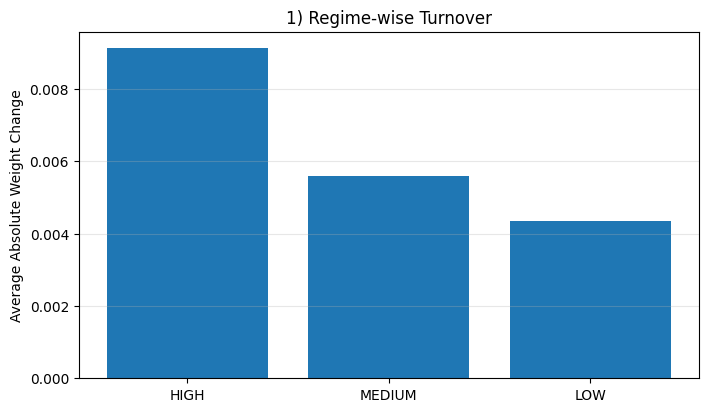

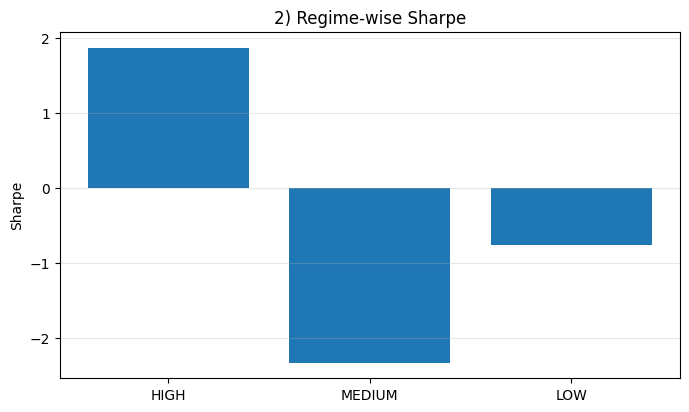

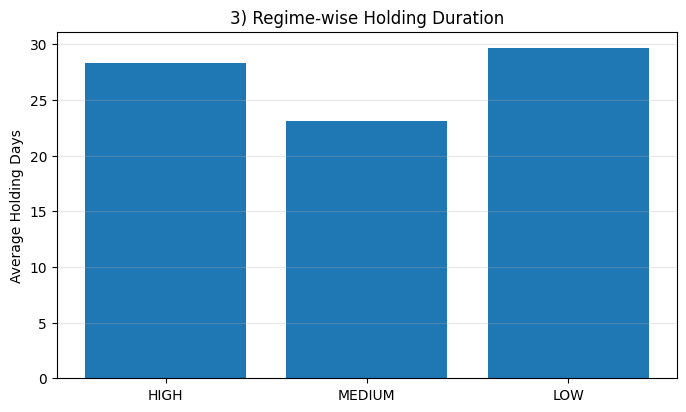

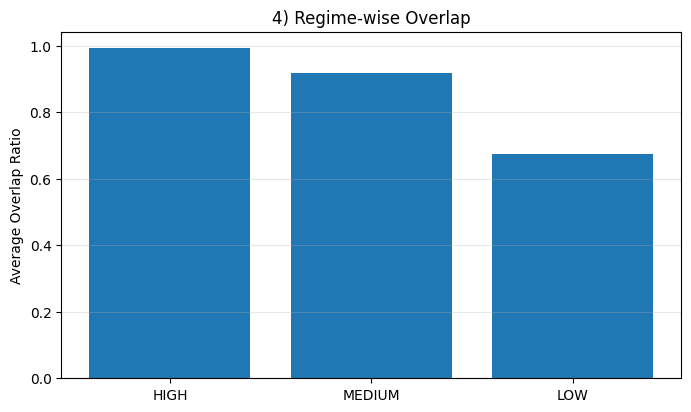

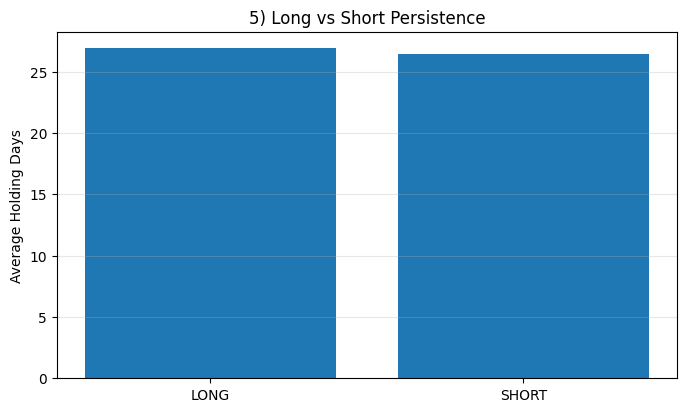

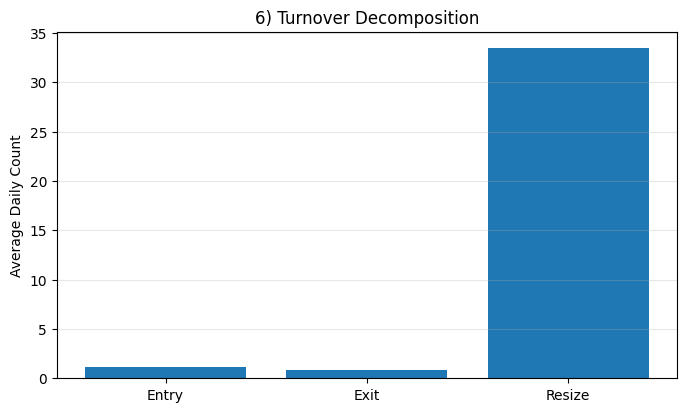

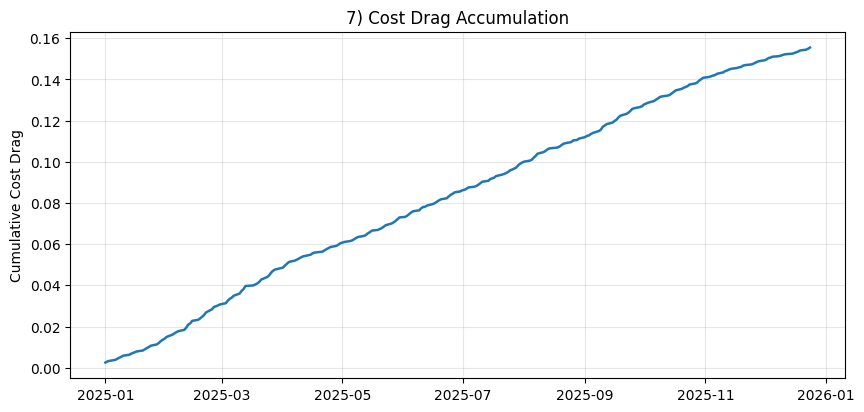

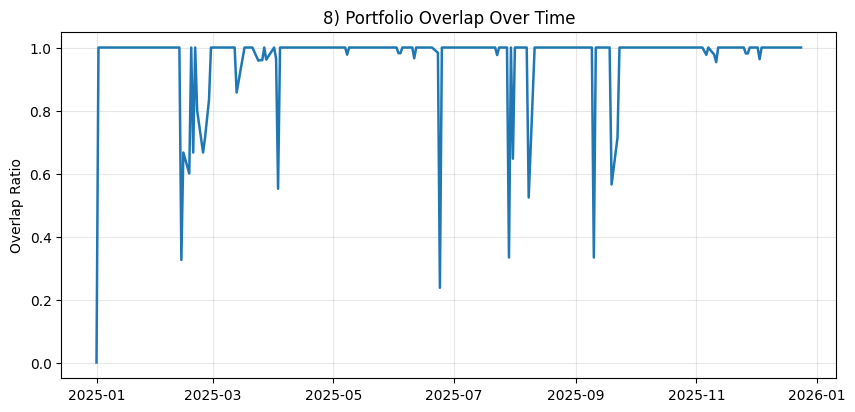

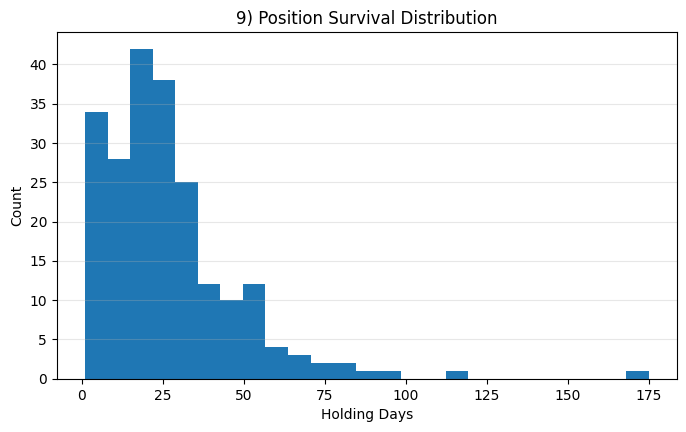

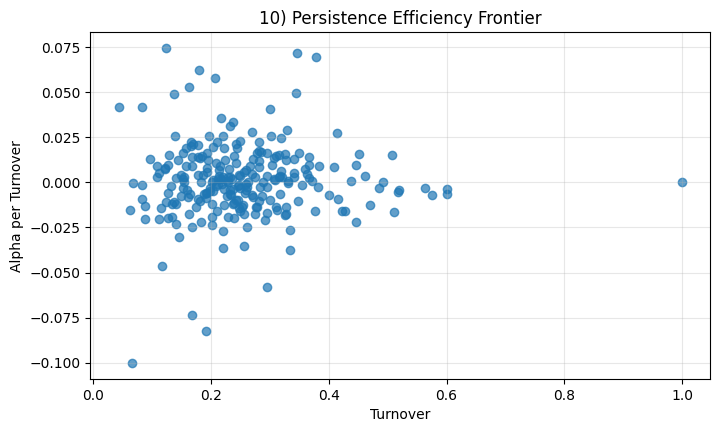

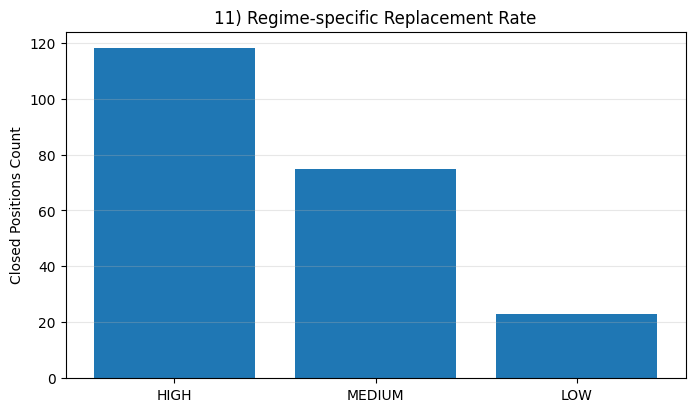

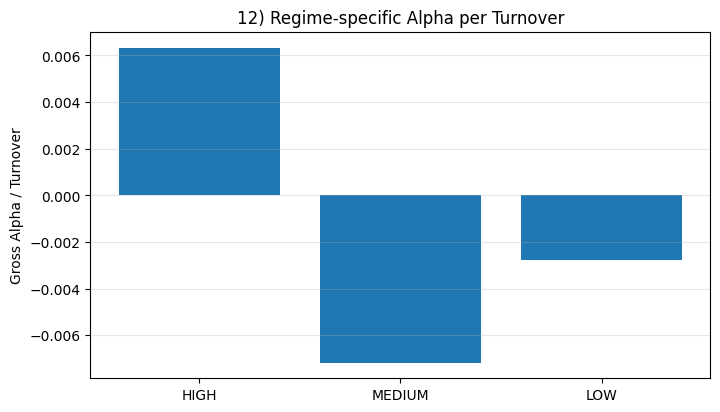

In [5]:
# 1) Regime-wise turnover
reg_turn = pnl_r.groupby("regime")["delta_weight"].apply(lambda s: float(np.mean(np.abs(s)))).reindex(CFG["regimes"])
plt.figure(figsize=(8, 4.5))
plt.bar(reg_turn.index, reg_turn.values)
plt.title("1) Regime-wise Turnover")
plt.ylabel("Average Absolute Weight Change")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 2) Regime-wise Sharpe (gross contribution series)
reg_sh = []
for r in CFG["regimes"]:
    s = pnl_r[pnl_r["regime"] == r].groupby("date")["gross_component"].sum().reset_index()
    m = annualized_metrics(s.rename(columns={"gross_component": "ret"}), "ret", turnover_col="ret")
    reg_sh.append((r, m["sharpe"]))
reg_sh_df = pd.DataFrame(reg_sh, columns=["regime", "sharpe"]).set_index("regime").reindex(CFG["regimes"])
plt.figure(figsize=(8, 4.5))
plt.bar(reg_sh_df.index, reg_sh_df["sharpe"].values)
plt.title("2) Regime-wise Sharpe")
plt.ylabel("Sharpe")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 3) Regime-wise holding duration
hold_reg = closed_r.groupby("entry_regime")["holding_days"].mean().reindex(CFG["regimes"]) if len(closed_r) else pd.Series(index=CFG["regimes"], dtype=float)
plt.figure(figsize=(8, 4.5))
plt.bar(hold_reg.index, hold_reg.values)
plt.title("3) Regime-wise Holding Duration")
plt.ylabel("Average Holding Days")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 4) Regime-wise overlap
ov_reg = pnl_r.groupby(["date", "regime"]).agg(held_prev=("held_prev", "sum"), held_new=("held_new", "sum")).reset_index()
ov_reg["overlap"] = np.minimum(ov_reg["held_prev"], ov_reg["held_new"]) / np.maximum(ov_reg["held_prev"], 1)
ov_bar = ov_reg.groupby("regime")["overlap"].mean().reindex(CFG["regimes"])
plt.figure(figsize=(8, 4.5))
plt.bar(ov_bar.index, ov_bar.values)
plt.title("4) Regime-wise Overlap")
plt.ylabel("Average Overlap Ratio")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 5) Long vs short persistence
ls_plot = long_short_analysis.set_index("side") if len(long_short_analysis) else pd.DataFrame(index=["LONG", "SHORT"], columns=["avg_holding_days"])
plt.figure(figsize=(8, 4.5))
plt.bar(ls_plot.index, ls_plot["avg_holding_days"].values)
plt.title("5) Long vs Short Persistence")
plt.ylabel("Average Holding Days")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 6) Turnover decomposition
decomp = {
    "Entry": float(turnover_analysis["entered_count"].mean()),
    "Exit": float(turnover_analysis["exited_count"].mean()),
    "Resize": float(turnover_analysis["resized_count"].mean()),
}
plt.figure(figsize=(8, 4.5))
plt.bar(list(decomp.keys()), list(decomp.values()))
plt.title("6) Turnover Decomposition")
plt.ylabel("Average Daily Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 7) Cost drag accumulation
cum_cost = turnover_analysis[["date", "cost_drag"]].copy()
cum_cost["cum_cost_drag"] = cum_cost["cost_drag"].cumsum()
plt.figure(figsize=(10, 4.5))
plt.plot(cum_cost["date"], cum_cost["cum_cost_drag"], linewidth=1.8)
plt.title("7) Cost Drag Accumulation")
plt.ylabel("Cumulative Cost Drag")
plt.grid(alpha=0.3)
plt.show()

# 8) Portfolio overlap over time
plt.figure(figsize=(10, 4.5))
plt.plot(turnover_analysis["date"], turnover_analysis["overlap_ratio"], linewidth=1.8)
plt.title("8) Portfolio Overlap Over Time")
plt.ylabel("Overlap Ratio")
plt.grid(alpha=0.3)
plt.show()

# 9) Position survival distribution
plt.figure(figsize=(8, 4.5))
plt.hist(closed_r["holding_days"].dropna() if len(closed_r) else pd.Series(dtype=float), bins=25)
plt.title("9) Position Survival Distribution")
plt.xlabel("Holding Days")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 10) Persistence efficiency frontier
front = turnover_analysis.copy()
front["x_turnover"] = front["turnover"]
front["y_eff"] = front["alpha_per_turnover"]
plt.figure(figsize=(8, 4.5))
plt.scatter(front["x_turnover"], front["y_eff"], alpha=0.7)
plt.title("10) Persistence Efficiency Frontier")
plt.xlabel("Turnover")
plt.ylabel("Alpha per Turnover")
plt.grid(alpha=0.3)
plt.show()

# 11) Regime-specific replacement rate
if len(closed_r):
    rr = closed_r.groupby("entry_regime")["ticker"].count().reindex(CFG["regimes"]).fillna(0)
else:
    rr = pd.Series([0, 0, 0], index=CFG["regimes"])
plt.figure(figsize=(8, 4.5))
plt.bar(rr.index, rr.values)
plt.title("11) Regime-specific Replacement Rate")
plt.ylabel("Closed Positions Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 12) Regime-specific alpha-per-turnover
apt = regime_analysis.set_index("regime")["alpha_per_turnover"].reindex(CFG["regimes"]) if len(regime_analysis) else pd.Series(index=CFG["regimes"], dtype=float)
plt.figure(figsize=(8, 4.5))
plt.bar(apt.index, apt.values)
plt.title("12) Regime-specific Alpha per Turnover")
plt.ylabel("Gross Alpha / Turnover")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Final Research Conclusions and Deployability Verdict

This section programmatically answers all eight research questions and prints a final verdict based on turnover reduction, net Sharpe, and cost-adjusted survivability.

In [6]:
display(Markdown("### Final Research Q&A"))
display(summary_df[["research_question", "answer"]])
display(Markdown(f"### Final Verdict: **{verdict}**"))

display(Markdown("### Persistence Economics Notes"))
display(Markdown(
    "- Regime-adaptive deadbands suppress low-value resizing churn.\n"
    "- Position survival and overlap explicitly capture institutional stability.\n"
    "- Alpha decay is managed through regime-specific hold and replacement thresholds.\n"
    "- Execution churn is treated as a first-class optimization target, not a by-product."
))

target_msg = "Target achieved (<0.25)" if (np.isfinite(step343_turn) and step343_turn < 0.25) else "Target not yet fully achieved"
print(f"Turnover target status: {target_msg}")
print(f"Step-34.2 reference turnover: {step342_turn:.4f}")
print(f"Step-34.3 turnover: {step343_turn:.4f}")
print(f"Step-34.3 net Sharpe: {step343_net_sh:.4f}")
print(f"Uniform-rules net Sharpe: {uniform_net_sh:.4f}")


### Final Research Q&A

,research_question,answer
0,1. Which regime benefits most from persistence?,HIGH regime (highest alpha-per-turnover).
1,2. Which regime causes most turnover destruction?,HIGH regime (largest cost drag).
2,3. Did regime-adaptive execution improve deplo...,YES
3,4. Did turnover materially decline?,YES (Δturnover=0.6496)
4,5. Is long-short deployment still justified?,"Conditional: longs strong, shorts require tigh..."
5,6. Should LOW regime be retained?,Retain selectively.
6,7. Which execution profile was most stable?,Uniform profile
7,8. Is the strategy economically deployable now?,NO


### Final Verdict: **FAIL**

### Persistence Economics Notes

- Regime-adaptive deadbands suppress low-value resizing churn.
- Position survival and overlap explicitly capture institutional stability.
- Alpha decay is managed through regime-specific hold and replacement thresholds.
- Execution churn is treated as a first-class optimization target, not a by-product.

Turnover target status: Target not yet fully achieved
Step-34.2 reference turnover: 0.9035
Step-34.3 turnover: 0.2539
Step-34.3 net Sharpe: -1.0561
Uniform-rules net Sharpe: -1.4282
